In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json, os
from scipy import stats
import pandas as pd
from tools import get_as_results, get_parallel_results, to_table, combine_algorithm_selection_score, compute_mcnemar, get_as_accuracy_results, compare_as_accuracy_results, compare_par_results
from sklearn.metrics import accuracy_score

In [4]:
total = {
    'wln-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wln-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wlne-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wlne-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wlc-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wlc-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},

    'wlce-1': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
    'wlce-2': {'scores': {'svc': [], 'forest': [], 'nn': []}, 'accuracy': {'svc': [], 'forest': [], 'nn': []}, 'par': {'svc': [], 'forest': [], 'nn': []}},
}

score_folder = '../data/as-scores-results/'
for model in ['svc', 'forest', 'nn']:
    folder = score_folder + model + '-scores/'
    for file in os.listdir(folder):
        assert 'json' in file
        if not "alllevels" in file:
            continue
        mn = model if model != 'forest' else 'rnd-forest'
        feature_set = file.replace('as_', '').replace('_alllevels', '').split(f'-{mn}-')[0]
        if feature_set in total:
            total[feature_set]['scores'][model].append(file)
from pprint import pp
for feature_set in total.keys():
    for model in ['svc', 'forest', 'nn']:
        assert len(total[feature_set]['scores'][model]) == len(set(total[feature_set]['scores'][model]))
        total[feature_set]['scores'][model] = len(total[feature_set]['scores'][model])

accuracy_folder = '../data/as-accuracy-results/'
for model in ['svc', 'forest', 'nn']:
    folder = accuracy_folder + model + '-scores/'
    for file in os.listdir(folder):
        assert 'json' in file
        if not "alllevels" in file:
            continue
        mn = model if model != 'forest' else 'rnd-forest'
        feature_set = file.replace('as-accuracy_', '').replace('_alllevels', '').split(f'-{mn}-')[0]
        if feature_set in total:
            total[feature_set]['accuracy'][model].append(file)
from pprint import pp
for feature_set in total.keys():
    for model in ['svc', 'forest', 'nn']:
        assert len(total[feature_set]['accuracy'][model]) == len(set(total[feature_set]['accuracy'][model]))
        total[feature_set]['accuracy'][model] = len(total[feature_set]['accuracy'][model])

parallel_folder = '../data/parallelise-results/'
for model in ['svc', 'forest', 'nn']:
    folder = parallel_folder + model + '-parallelise/'
    for file in os.listdir(folder):
        assert 'json' in file
        if not "alllevels" in file:
            continue
        mn = model if model != 'forest' else 'rnd-forest'
        feature_set = file.replace('par_', '').replace('_alllevels', '').split(f'-{mn}-')[0]
        if feature_set in total:
            total[feature_set]['par'][model].append(file)
from pprint import pp
for feature_set in total.keys():
    for model in ['svc', 'forest', 'nn']:
        assert len(total[feature_set]['par'][model]) == len(set(total[feature_set]['par'][model]))
        total[feature_set]['par'][model] = len(total[feature_set]['par'][model])

total_missing = 0
for feature_set in total.keys():
    print("===========================================")
    total_missing += (50 - total[feature_set]["scores"]["svc"]) + (50 - total[feature_set]["scores"]["forest"]) + (50 - total[feature_set]["scores"]["nn"]) \
                   + (50 - total[feature_set]["accuracy"]["svc"]) + (50 - total[feature_set]["accuracy"]["forest"]) + (50 - total[feature_set]["accuracy"]["nn"]) \
                   + (50 - total[feature_set]["par"]["svc"]) + (50 - total[feature_set]["par"]["forest"]) + (50 - total[feature_set]["par"]["nn"])
    print(f'''{feature_set}: 
scores: ({50 - total[feature_set]["scores"]["svc"]}, {50 - total[feature_set]["scores"]["forest"]}, {50 - total[feature_set]["scores"]["nn"]})
accuracy: ({50 - total[feature_set]["accuracy"]["svc"]}, {50 - total[feature_set]["accuracy"]["forest"]}, {50 - total[feature_set]["accuracy"]["nn"]})
parallel: ({50 - total[feature_set]["par"]["svc"]}, {50 - total[feature_set]["par"]["forest"]}, {50 - total[feature_set]["par"]["nn"]})''')

print("total missing experiments:", total_missing)

wln-1: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
wln-2: 
scores: (0, 0, 26)
accuracy: (0, 0, 27)
parallel: (0, 0, 3)
wlne-1: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
wlne-2: 
scores: (0, 0, 23)
accuracy: (0, 0, 23)
parallel: (0, 0, 7)
wlc-1: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
wlc-2: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
wlce-1: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
wlce-2: 
scores: (0, 0, 0)
accuracy: (0, 0, 0)
parallel: (0, 0, 0)
total missing experiments: 109


# Borda-count Scores

In [ ]:
folder = '../data/as-scores-results/svc-scores'
dataset = '../data/algorithm_selection_dataset_score.csv'
print(folder, ':')
res_svc = get_as_results(folder, True)
fzn2feat = list(res_svc['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res_svc['wlc-1'].values()), fzn2feat)
print("wlc-1:", p_value)
t_stat, p_value = stats.wilcoxon(list(res_svc['wlc-2'].values()), fzn2feat)
print("wlc-2:", p_value)
display(to_table(res_svc))

../data/as-scores-results/svc-scores :
wlc-1: 0.002996250182501825
wlc-2: 0.01958777690517799


,Mean,Median,Std,Max,Min,Worse_sbs
wln-2-alllevels,0.242538,0.265585,0.184058,0.596341,-0.411439,4
wlne-2-alllevels,0.235620,0.265585,0.196754,0.596341,-0.461698,5
wln-2,0.282667,0.276099,0.149708,0.586188,-0.102522,2
wlc-1,0.484961,0.506030,0.160183,0.743272,0.070355,0
wln-1,0.210201,0.244648,0.188278,0.499440,-0.336539,7
wl-2,0.117820,0.164678,0.237195,0.563621,-0.738837,13
wlc-1-alllevels,0.440731,0.472945,0.186146,0.753592,-0.080500,2
wln-1-alllevels,0.196332,0.237227,0.177886,0.499440,-0.229068,8
wlce-1,0.469664,0.512524,0.192812,0.731465,-0.354095,1
wlne-2,0.275569,0.274540,0.167006,0.612715,-0.129162,3


../data/as-scores-results/svc-scores :


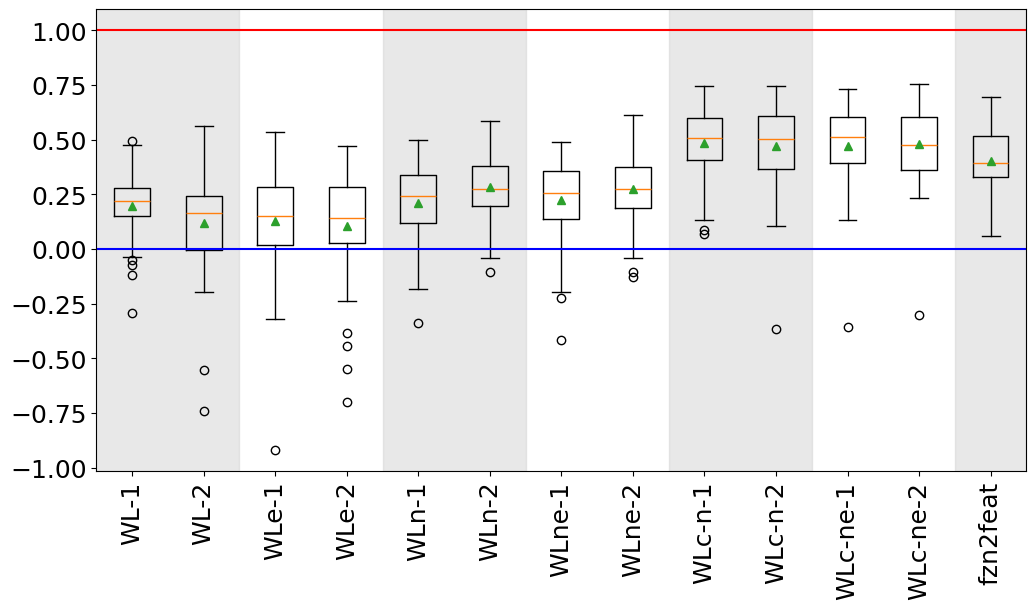

In [53]:
folder = '../data/as-scores-results/svc-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_results(folder, False)
plot_res = {
    features.replace("wlc", "wlc-n"): list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.axhline(y=1, c='red')
ax.axhline(y=0, c='blue')

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(0, 2.5, color='lightgrey', alpha=0.5)
ax.axvspan(4.5, 6.5, color='lightgrey', alpha=0.5)
ax.axvspan(8.5, 10.5, color='lightgrey', alpha=0.5)
ax.axvspan(12.5, 13.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [k.replace("wl", "WL") for k in plot_res.keys()], rotation='vertical')
plt.savefig('../paper/figures/wl_score_svc.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [60]:
table_res = {'last-mean':{}, 
        'all-levels-mean':{}, 
        'last-median':{}, 
        'all-levels-median':{}, 
        'significant': {}}
for features in plot_res.keys():
    if not 'alllevels' in features:
        continue
    last_feat = features.replace('-alllevels', '')
    table_res['last-mean'][last_feat] = f'{np.mean(plot_res[last_feat]):.3f}'
    table_res['last-median'][last_feat] = f'{np.median(plot_res[last_feat]):.3f}'
    table_res['all-levels-mean'][last_feat] = f'{np.mean(plot_res[features]):.3f}'
    table_res['all-levels-median'][last_feat] = f'{np.median(plot_res[features]):.3f}'
    _, p = stats.wilcoxon(plot_res[last_feat], plot_res[features])
    color = 'forestgreen' if p > 0.05 else 'red'
    table_res['significant'][last_feat] = '\\textcolor{' + color + '}{' f'{p:.3f}' '}'

print(pd.DataFrame(table_res).to_latex())

\begin{tabular}{llllll}
\toprule
 & last-mean & all-levels-mean & last-median & all-levels-median & significant \\
\midrule
wln-2 & 0.283 & 0.243 & 0.276 & 0.266 & \textcolor{forestgreen}{0.357} \\
wlne-2 & 0.276 & 0.236 & 0.275 & 0.266 & \textcolor{forestgreen}{0.201} \\
wlc-1 & 0.485 & 0.441 & 0.506 & 0.473 & \textcolor{forestgreen}{0.399} \\
wln-1 & 0.210 & 0.196 & 0.245 & 0.237 & \textcolor{forestgreen}{0.632} \\
wlce-2 & 0.479 & 0.432 & 0.475 & 0.460 & \textcolor{forestgreen}{0.318} \\
wlce-1 & 0.470 & 0.440 & 0.513 & 0.487 & \textcolor{forestgreen}{0.681} \\
wlc-2 & 0.472 & 0.432 & 0.504 & 0.456 & \textcolor{forestgreen}{0.198} \\
wlne-1 & 0.226 & 0.212 & 0.258 & 0.245 & \textcolor{forestgreen}{0.561} \\
\bottomrule
\end{tabular}



In [35]:
print('Statistical significance matrix (no fzn2feat):')
folder = '../data/as-scores-results/svc-scores'
WORSE = '\\textcolor{red}{$\\times$}'
BETTER = '\\textcolor{ForestGreen}{\\checkmark}'
EQUAL = '\\textbf{--}'

res_svc = get_as_results(folder)
features = [f for f in res_svc.keys() if f != 'fzn2feat']
features.append('fzn2feat')
rows = {feat.replace("wlc", "WLc-n"):{ft.replace("wlc", "WLc-n"):'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:
        if ft1 == ft2:
            rows[ft1.replace("wlc", "WLc-n")][ft2.replace("wlc", "WLc-n")] = 0
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2.replace("wlc", "WLc-n")][ft1.replace("wlc", "WLc-n")] = p_value
            else:
                rows[ft2.replace("wlc", "WLc-n")][ft1.replace("wlc", "WLc-n")] = p_value
        else:
            rows[ft1.replace("wlc", "WLc-n")][ft2.replace("wlc", "WLc-n")] = p_value
display(pd.DataFrame(rows))

Statistical significance matrix (no fzn2feat):


,wl-1,wl-2,wle-1,wle-2,wln-1,wln-2,wlne-1,wlne-2,WLc-n-1,WLc-n-2,WLc-ne-1,WLc-ne-2,fzn2feat
wl-1,0.000000e+00,4.830954e-02,1.433326e-01,6.780370e-02,6.051405e-01,5.579490e-03,3.472069e-01,2.122367e-02,2.308020e-11,2.023217e-10,8.855281e-10,2.023217e-10,3.489742e-10
wl-2,4.830954e-02,0.000000e+00,6.458760e-01,9.771032e-01,9.116961e-03,7.946968e-06,1.368693e-02,1.628744e-04,1.953993e-13,1.768719e-11,2.813216e-10,1.192392e-09,3.881979e-10
wle-1,1.433326e-01,6.458760e-01,0.000000e+00,3.988547e-01,1.139399e-01,1.147178e-03,2.012064e-02,1.842533e-03,4.911627e-12,2.563333e-09,3.705512e-09,2.813216e-10,2.022027e-11
wle-2,6.780370e-02,9.771032e-01,3.988547e-01,0.000000e+00,1.757545e-02,3.825853e-04,2.049095e-03,2.308750e-04,2.022027e-11,5.610268e-11,1.146780e-10,7.940315e-13,4.960476e-11
wln-1,6.051405e-01,9.116961e-03,1.139399e-01,1.757545e-02,0.000000e+00,1.117184e-01,7.521534e-01,1.433326e-01,6.337864e-11,3.623270e-08,4.792291e-10,4.857153e-09,1.619818e-07
wln-2,5.579490e-03,7.946968e-06,1.147178e-03,3.825853e-04,1.117184e-01,0.000000e+00,1.749876e-01,8.345306e-01,5.340621e-08,2.670359e-06,3.094002e-08,1.867326e-07,3.825853e-04
wlne-1,3.472069e-01,1.368693e-02,2.012064e-02,2.049095e-03,7.521534e-01,1.749876e-01,0.000000e+00,3.136656e-01,8.855281e-10,5.310079e-09,4.945666e-08,4.236403e-08,1.132623e-06
wlne-2,2.122367e-02,1.628744e-04,1.842533e-03,2.308750e-04,1.433326e-01,8.345306e-01,3.136656e-01,0.000000e+00,3.731212e-07,2.003957e-07,1.859967e-06,2.649707e-07,7.549340e-04
WLc-n-1,2.308020e-11,1.953993e-13,4.911627e-12,2.022027e-11,6.337864e-11,5.340621e-08,8.855281e-10,3.731212e-07,0.000000e+00,8.858856e-01,7.448959e-01,9.161858e-01,2.996250e-03
WLc-n-2,2.023217e-10,1.768719e-11,2.563333e-09,5.610268e-11,3.623270e-08,2.670359e-06,5.310079e-09,2.003957e-07,8.858856e-01,0.000000e+00,9.542250e-01,9.010180e-01,1.958778e-02


In [4]:
folder = '../data/as-scores-results/forest-scores'
print(folder, ':')
res_forest = get_as_results(folder)
fzn2feat = list(res_forest['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res_forest['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res_forest['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
display(to_table(res_forest))

../data/as-scores-results/forest-scores :
wlc-1: 0.5526669770606443
wlc-2: 0.6736344940466168


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.453126,0.469145,0.169899,0.793287,-0.085975,1
wl-1,0.247356,0.262464,0.141575,0.505527,-0.191213,3
wle-1,0.349537,0.357495,0.164811,0.645770,-0.173245,1
wle-2,0.429101,0.432580,0.123101,0.747006,0.167517,0
wln-1,0.430599,0.433760,0.140518,0.747006,0.042360,0
wln-2,0.448705,0.454461,0.133005,0.668731,0.165787,0
wlne-1,0.439817,0.446640,0.110832,0.648780,0.184772,0
wlne-2,0.432966,0.412279,0.125370,0.668731,0.116504,0
wlc-1,0.442881,0.443803,0.141967,0.790252,0.172934,0
wlc-2,0.449713,0.443803,0.137703,0.715554,0.106153,0


../data/as-scores-results/forest-scores :


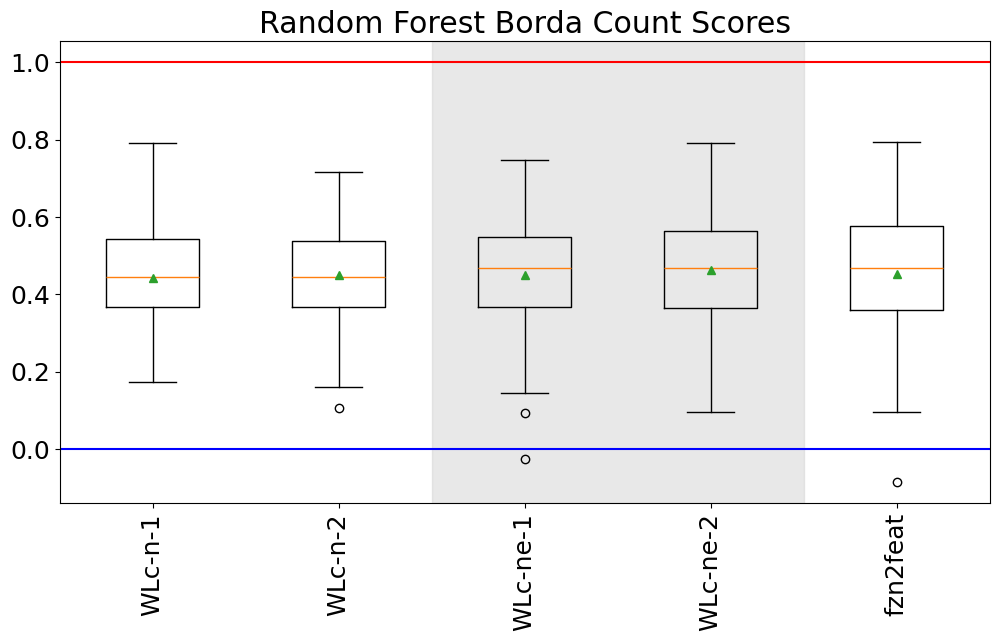

In [7]:
folder = '../data/as-scores-results/forest-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_results(folder)
plot_res = {
    features.replace("wlc", "wlc-n"): list(v.values()) for features, v in res_svc.items() if 'wlc' in features or 'fzn2feat' in features
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.axhline(y=1, c='red')
ax.axhline(y=0, c='blue')
# ax.axhline(y=np.mean(plot_res['wlnc-1']), c='green')

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)
ax.set_title("Random Forest Borda Count Scores")


plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [k.replace("wl", "WL") for k in plot_res.keys()], rotation='vertical')
plt.savefig('../paper/figures/wl-fzn2feat_score_forest.pdf', format='pdf', bbox_inches='tight',)
plt.show()

../data/as-scores-results/forest-scores :


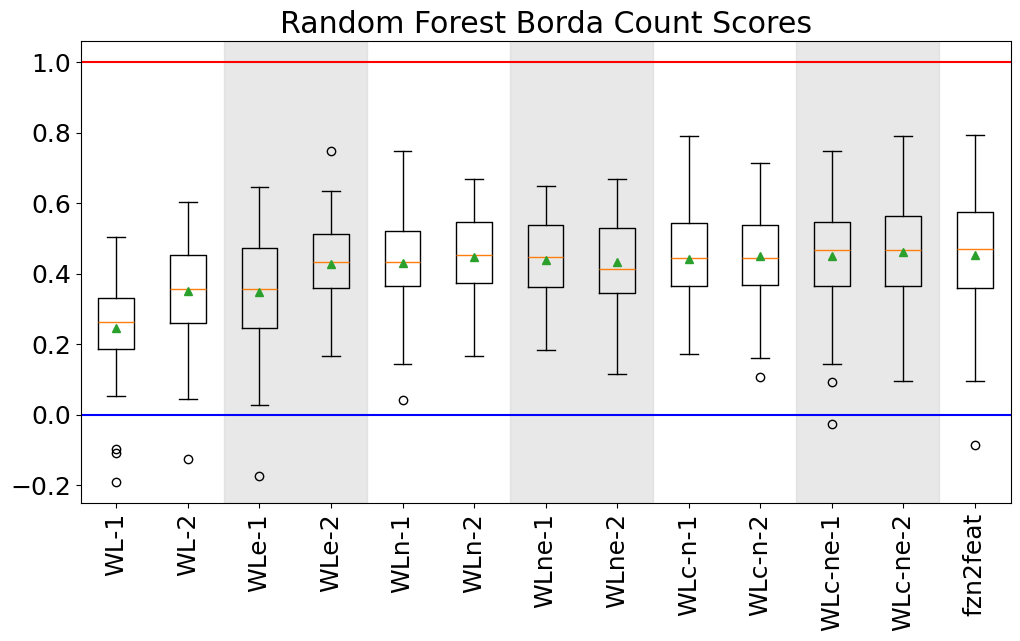

In [37]:
folder = '../data/as-scores-results/forest-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_results(folder)
plot_res = {
    features.replace("wlc", "wlc-n"): list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.axhline(y=1, c='red')
ax.axhline(y=0, c='blue')
# ax.axhline(y=np.mean(plot_res['wlnc-1']), c='green')

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)
ax.set_title("Random Forest Borda Count Scores")


plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [k.replace("wl", "WL") for k in plot_res.keys()], rotation='vertical')
plt.savefig('../paper/figures/all-wl-fzn2feat_score_forest.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [13]:
table_res = {'last-mean':{}, 
        'all-levels-mean':{}, 
        'last-median':{}, 
        'all-levels-median':{}, 
        'significant': {}}
# plot_res = get_as_results(folder, True)
res_svc = get_as_results(folder, True)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
for features in plot_res.keys():
    if not 'alllevels' in features:
        continue
    last_feat = features.replace('_alllevels', '')
    table_res['last-mean'][last_feat.replace("wlc", "WLc-n")] = f'{np.mean(plot_res[last_feat]):.3f}'
    table_res['last-median'][last_feat.replace("wlc", "WLc-n")] = f'{np.median(plot_res[last_feat]):.3f}'
    table_res['all-levels-mean'][last_feat.replace("wlc", "WLc-n")] = f'{np.mean(plot_res[features]):.3f}'
    table_res['all-levels-median'][last_feat.replace("wlc", "WLc-n")] = f'{np.median(plot_res[features]):.3f}'
    _, p = stats.wilcoxon(plot_res[last_feat], plot_res[features])
    color = 'forestgreen' if p > 0.05 else 'red'
    table_res['significant'][last_feat.replace("wlc", "WLc-n")] = '\\textcolor{' + color + '}{' f'{p:.3f}' '}'

print(pd.DataFrame(table_res).to_latex())

\begin{tabular}{llllll}
\toprule
 & last-mean & all-levels-mean & last-median & all-levels-median & significant \\
\midrule
wlne-2 & 0.433 & 0.475 & 0.412 & 0.488 & \textcolor{forestgreen}{0.114} \\
WLc-ne-1 & 0.450 & 0.456 & 0.469 & 0.484 & \textcolor{forestgreen}{0.774} \\
wlne-1 & 0.440 & 0.452 & 0.447 & 0.455 & \textcolor{forestgreen}{0.509} \\
WLc-ne-2 & 0.462 & 0.450 & 0.468 & 0.445 & \textcolor{forestgreen}{0.472} \\
wln-1 & 0.431 & 0.464 & 0.434 & 0.486 & \textcolor{forestgreen}{0.318} \\
wln-2 & 0.449 & 0.464 & 0.454 & 0.465 & \textcolor{forestgreen}{0.745} \\
WLc-n-1 & 0.443 & 0.460 & 0.444 & 0.465 & \textcolor{forestgreen}{0.608} \\
WLc-n-2 & 0.450 & 0.449 & 0.444 & 0.459 & \textcolor{forestgreen}{0.863} \\
\bottomrule
\end{tabular}



In [38]:
print('Statistical significance matrix (fzn2feat -vs- wlc):')
folder = '../data/as-scores-results/forest-scores'
WORSE = 'W'
BETTER = 'B'
EQUAL = 'E'

res_svc = get_as_results(folder)
features = [f for f in res_svc.keys() if not "alllevels" in f]
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:
        # if ft1 == 'wlce-2' or ft2 == 'wlce-2':
        #     continue 
        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER + f'({p_value:.2f})'
            else:
                rows[ft2][ft1] = WORSE + f'({p_value:.2f})'
        else:
            rows[ft2][ft1] = EQUAL + f'({p_value:.2f})'
display(pd.DataFrame(rows))

Statistical significance matrix (fzn2feat -vs- wlc):


,fzn2feat,wl-1,wl-2,wle-1,wle-2,wln-1,wln-2,wlne-1,wlne-2,wlc-1,wlc-2,wlce-1,wlce-2
fzn2feat,E,B(0.00),B(0.00),B(0.01),E(0.54),E(0.42),E(0.64),E(0.58),E(0.43),E(0.55),E(0.67),E(0.78),E(0.52)
wl-1,W(0.00),E,W(0.00),W(0.00),W(0.00),W(0.00),W(0.00),W(0.00),W(0.00),W(0.00),W(0.00),W(0.00),W(0.00)
wl-2,W(0.00),B(0.00),E,E(1.00),W(0.00),W(0.01),W(0.00),W(0.00),W(0.01),W(0.00),W(0.00),W(0.00),W(0.00)
wle-1,W(0.01),B(0.00),E(1.00),E,W(0.01),W(0.01),W(0.00),W(0.01),W(0.01),W(0.00),W(0.00),W(0.00),W(0.00)
wle-2,E(0.54),B(0.00),B(0.00),B(0.01),E,E(0.89),E(0.33),E(0.61),E(0.87),E(0.53),E(0.30),E(0.28),E(0.30)
wln-1,E(0.42),B(0.00),B(0.01),B(0.01),E(0.89),E,E(0.29),E(0.87),E(0.86),E(0.77),E(0.53),E(0.68),E(0.33)
wln-2,E(0.64),B(0.00),B(0.00),B(0.00),E(0.33),E(0.29),E,E(0.62),E(0.47),E(0.61),E(0.98),E(0.87),E(0.63)
wlne-1,E(0.58),B(0.00),B(0.00),B(0.01),E(0.61),E(0.87),E(0.62),E,E(0.63),E(0.98),E(0.80),E(0.61),E(0.29)
wlne-2,E(0.43),B(0.00),B(0.01),B(0.01),E(0.87),E(0.86),E(0.47),E(0.63),E,E(0.78),E(0.47),E(0.45),E(0.29)
wlc-1,E(0.55),B(0.00),B(0.00),B(0.00),E(0.53),E(0.77),E(0.61),E(0.98),E(0.78),E,E(0.77),E(0.55),E(0.55)


In [19]:
folder = '../data/as-scores-results/nn-scores'
print(folder, ':')
res = get_as_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print("wlc-1:", p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print("wlc-2:", p_value)
# t_stat, p_value = stats.wilcoxon(list(res['wlce-1'].values()), fzn2feat)
# print("wlce-1:", p_value)
display(to_table(res))

../data/as-scores-results/nn-scores :
wlc-1: 0.05060520369320898
wlc-2: 0.056738698656332076


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.321337,0.337987,0.193624,0.617528,-0.211868,3
wl-1,-0.080718,-0.031576,0.252760,0.371451,-0.622757,27
wl-2,-0.029734,-0.027363,0.267504,0.418039,-0.853155,27
wln-1,0.192158,0.217793,0.232281,0.571335,-0.465970,10
wln-2,0.204180,0.252303,0.214191,0.525779,-0.327113,11
wlne-1,0.182753,0.224914,0.239562,0.580436,-0.652952,7
wlne-2,0.236365,0.289051,0.229208,0.603765,-0.405164,6
wlc-1,0.394406,0.412294,0.162838,0.680162,-0.150765,1
wlc-2,0.374693,0.380969,0.161457,0.652045,-0.072218,2
wlce-1,0.381225,0.378229,0.168196,0.740904,-0.150765,1


In [40]:
print('Statistical significance matrix (fzn2feat -vs- wlc):')
folder = '../data/as-scores-results/nn-scores'
WORSE = 'W'
BETTER = 'B'
EQUAL = 'E'

res_svc = get_as_results(folder)
features = [f for f in res_svc.keys() if f == 'fzn2feat' or 'wlc' in f]
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:

        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER + f'({p_value:.3f})'
            else:
                rows[ft2][ft1] = WORSE + f'({p_value:.3f})'
        else:
            rows[ft2][ft1] = EQUAL + f'({p_value:.3f})'
display(pd.DataFrame(rows))

Statistical significance matrix (fzn2feat -vs- wlc):


,fzn2feat,wlc-1,wlc-2,wlce-1,wlce-2
fzn2feat,E,E(0.051),E(0.057),E(0.051),E(0.065)
wlc-1,E(0.051),E,E(0.337),E(0.716),E(0.878)
wlc-2,E(0.057),E(0.337),E,E(0.886),E(0.347)
wlce-1,E(0.051),E(0.716),E(0.886),E,E(0.745)
wlce-2,E(0.065),E(0.878),E(0.347),E(0.745),E


../data/as-scores-results/nn-scores :


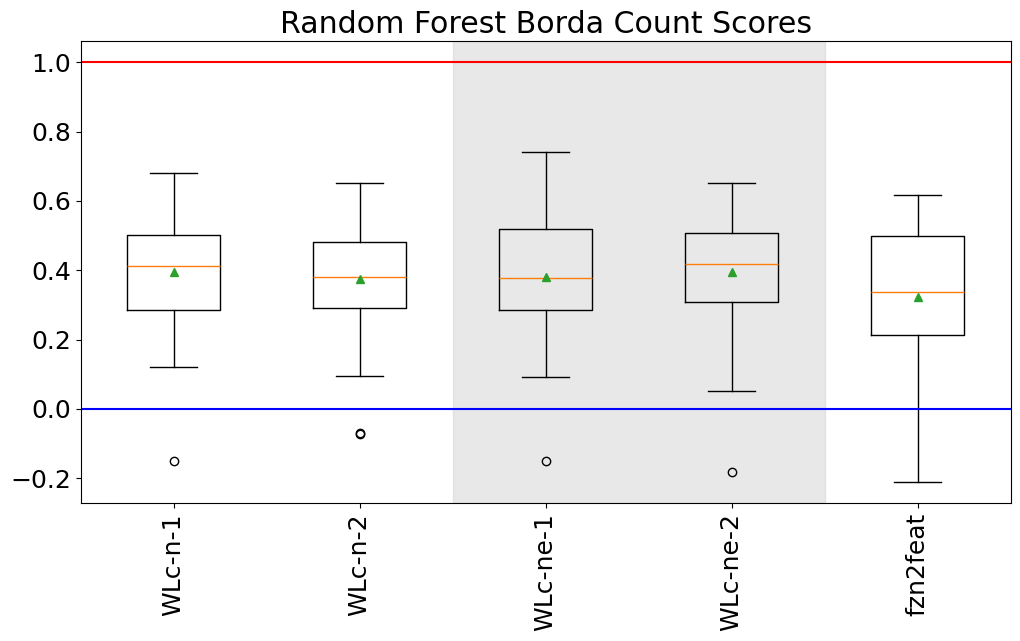

In [46]:
folder = '../data/as-scores-results/nn-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_results(folder)
plot_res = {
    features.replace("wlc", "wlc-n"): list(v.values()) for features, v in res_svc.items() 
    if 'wlc' in features or 'fzn2feat' == features
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.axhline(y=1, c='red')
ax.axhline(y=0, c='blue')
# ax.axhline(y=np.mean(plot_res['wlnc-1']), c='green')

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)
ax.set_title("Random Forest Borda Count Scores")


plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [k.replace("wl", "WL") for k in plot_res.keys()], rotation='vertical')
plt.savefig('../paper/figures/wl-fzn2feat_score_nn.pdf', format='pdf', bbox_inches='tight',)
plt.show()

../data/as-scores-results/nn-scores :


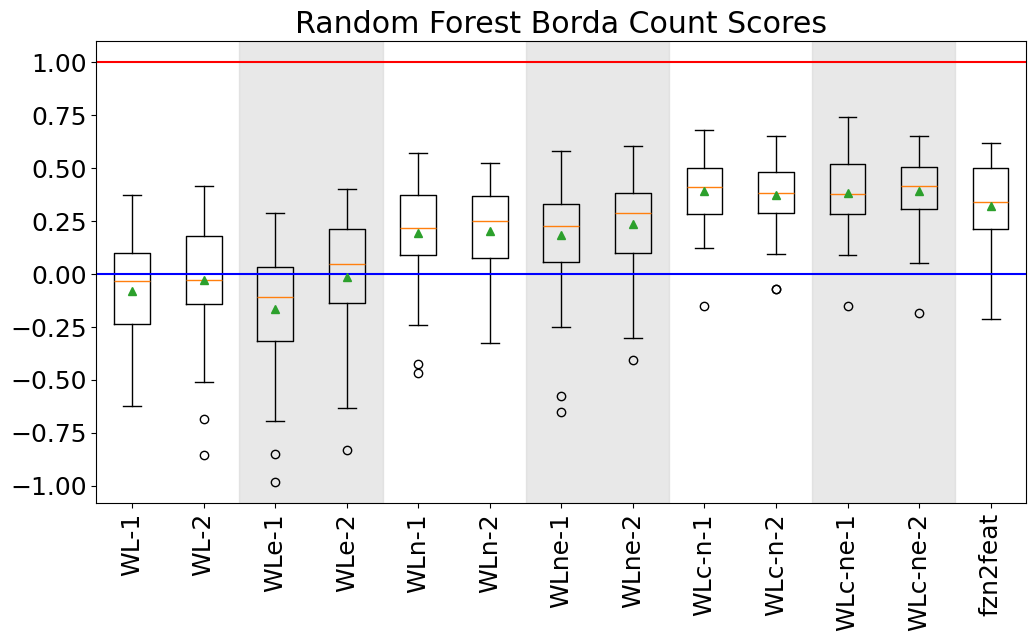

In [42]:
folder = '../data/as-scores-results/nn-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_results(folder)
plot_res = {
    features.replace("wlc", "wlc-n"): list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.axhline(y=1, c='red')
ax.axhline(y=0, c='blue')
# ax.axhline(y=np.mean(plot_res['wlnc-1']), c='green')

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)
ax.set_title("Random Forest Borda Count Scores")


plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [k.replace("wl", "WL") for k in plot_res.keys()], rotation='vertical')
plt.savefig('../paper/figures/all-wl-fzn2feat_score_nn.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [39]:
table_res = {'last-mean':{}, 
        'all-levels-mean':{}, 
        'last-median':{}, 
        'all-levels-median':{}, 
        'significant': {}}
folder = '../data/as-scores-results/nn-scores'

plot_res = get_as_results(folder, True)
plot_res = {
    features: list(v.values()) for features, v in plot_res.items()
}
for features in plot_res.keys():
    if not 'alllevels' in features:
        continue
    last_feat = features.replace('_alllevels', '')
    table_res['last-mean'][last_feat] = f'{np.mean(plot_res[last_feat]):.3f}'
    table_res['last-median'][last_feat] = f'{np.median(plot_res[last_feat]):.3f}'
    table_res['all-levels-mean'][last_feat] = f'{np.mean(plot_res[features]):.3f}'
    table_res['all-levels-median'][last_feat] = f'{np.median(plot_res[features]):.3f}'
    _, p = stats.wilcoxon(plot_res[last_feat], plot_res[features])
    color = 'forestgreen' if p > 0.05 else 'red'
    table_res['significant'][last_feat] = '\\textcolor{' + color + '}{' f'{p:.3f}' '}'

print(pd.DataFrame(table_res).to_latex())

ValueError: operands could not be broadcast together with shapes (50,) (49,) 

In [50]:
res_forest = get_as_results('../data/as-scores-results/forest-scores')
res_svc = get_as_results('../data/as-scores-results/svc-scores')
fzn2feat = list(res_forest['fzn2feat'].values())
print('fzn2feat', np.mean(fzn2feat), np.median(fzn2feat))
_, p_value = stats.wilcoxon(list(res_svc['wlc-1'].values()), fzn2feat)
print('wlc-1', np.mean(list(res_svc['wlc-1'].values())), np.median(list(res_svc['wlc-1'].values())), p_value)
_, p_value = stats.wilcoxon(list(res_svc['wlc-2'].values()), fzn2feat)
print('wlc-2', np.mean(list(res_svc['wlc-2'].values())), np.median(list(res_svc['wlc-2'].values())), p_value)
_, p_value = stats.wilcoxon(list(res_svc['wlce-1'].values()), fzn2feat)
print('wlce-1', np.mean(list(res_svc['wlce-1'].values())), np.median(list(res_svc['wlce-1'].values())), p_value)
_, p_value = stats.wilcoxon(list(res_svc['wlce-2'].values()), fzn2feat)
print('wlce-2', np.mean(list(res_svc['wlce-2'].values())), np.median(list(res_svc['wlce-2'].values())), p_value)

fzn2feat 0.45312622652320633 0.4691450182378498
wlc-1 0.484961040885506 0.5060300255419966 0.3673427625704484
wlc-2 0.4724658841465627 0.5036565790449037 0.3422827758111566
wlce-1 0.46966352656970406 0.512523833341318 0.3374027667706141
wlce-2 0.4786318642167334 0.4754384294316676 0.46647302992520423


# Algorithm Selection Accuracy Scores

In [31]:
compare_as_accuracy_results(('wlc-1', 'svc'),('fzn2feat', 'forest'), '../data/as-accuracy-results')

(0.6948096885813149, 0.6667820069204152, 0.0006394217955246711)

In [55]:
folder = '../data/as-accuracy-results/svc-scores'
print(folder, ':')
res = get_as_accuracy_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), list(res['wlc-1'].values()))
print('wlc-2:', p_value)
to_table(res, False)

../data/as-accuracy-results/svc-scores :
wlc-1: 1.6027711723756744e-05
wlc-2: 6.730663031992932e-05
wlc-2: 0.5113580487685174


,Mean,Median,Std,Max,Min
fzn2feat,0.628796,0.634755,0.058112,0.741379,0.517241
wl-1,0.569552,0.568966,0.059232,0.672414,0.421053
wle-1,0.586219,0.603448,0.080933,0.719298,0.362069
wln-1,0.588959,0.591349,0.052051,0.724138,0.465517
wln-2,0.606606,0.603448,0.049738,0.706897,0.482759
wlne-1,0.589310,0.599970,0.056227,0.724138,0.465517
wlne-2,0.605227,0.603448,0.050806,0.706897,0.482759
wlc-1,0.694737,0.681034,0.069942,0.879310,0.543860
wlc-2,0.686866,0.689655,0.066473,0.810345,0.551724
wlce-1,0.693019,0.689655,0.067105,0.810345,0.526316


../data/as-accuracy-results/svc-scores :


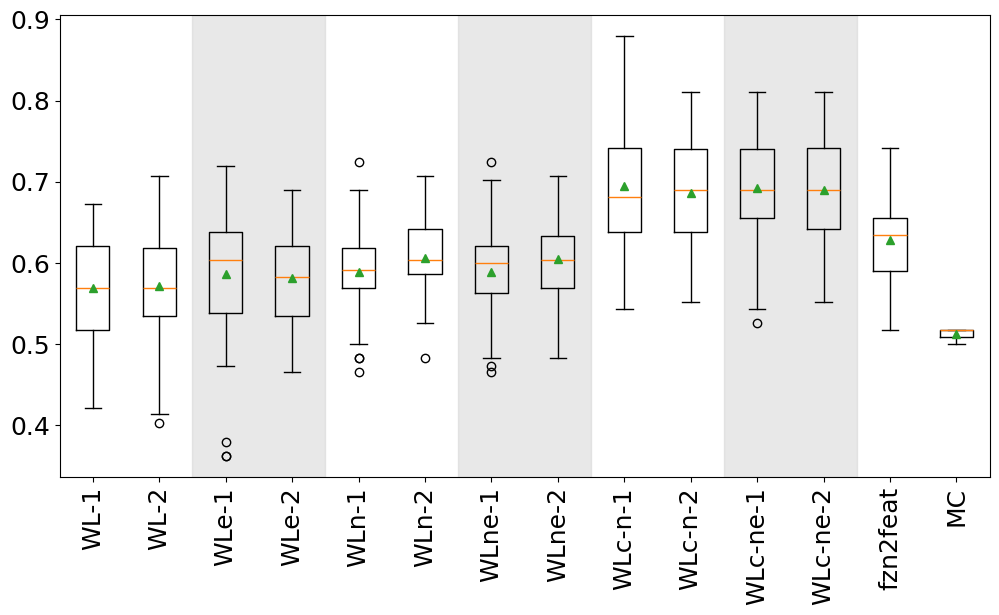

In [17]:
folder = '../data/as-accuracy-results/svc-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_as_accuracy_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

majority_classifier = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = majority_classifier
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wlc", "WLc-n").replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/wl_accuracy_svc.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [18]:
table_res = {'last-mean':{}, 
        'all-levels-mean':{}, 
        'last-median':{}, 
        'all-levels-median':{}, 
        'significant': {}}
folder = '../data/as-accuracy-results/svc-scores'


plot_res = get_as_accuracy_results(folder, True)
plot_res = {
    features: list(v.values()) for features, v in plot_res.items()
}
for features in plot_res.keys():
    if not 'alllevels' in features:
        continue
    last_feat = features.replace('_alllevels', '')
    table_res['last-mean'][last_feat.replace("wlc", "WLc-n")] = f'{np.mean(plot_res[last_feat]):.3f}'
    table_res['last-median'][last_feat.replace("wlc", "WLc-n")] = f'{np.median(plot_res[last_feat]):.3f}'
    table_res['all-levels-mean'][last_feat.replace("wlc", "WLc-n")] = f'{np.mean(plot_res[features]):.3f}'
    table_res['all-levels-median'][last_feat.replace("wlc", "WLc-n")] = f'{np.median(plot_res[features]):.3f}'
    _, p = stats.wilcoxon(plot_res[last_feat], plot_res[features])
    table_res['significant'][last_feat.replace("wlc", "WLc-n")] = f'{p:.3f}'

print(pd.DataFrame(table_res).to_latex())

\begin{tabular}{llllll}
\toprule
 & last-mean & all-levels-mean & last-median & all-levels-median & significant \\
\midrule
wln-2 & 0.607 & 0.591 & 0.603 & 0.603 & 0.217 \\
WLc-n-1 & 0.695 & 0.663 & 0.681 & 0.655 & 0.030 \\
WLc-ne-1 & 0.693 & 0.674 & 0.690 & 0.664 & 0.251 \\
wlne-2 & 0.605 & 0.604 & 0.603 & 0.603 & 0.974 \\
wlne-1 & 0.589 & 0.597 & 0.600 & 0.596 & 0.336 \\
WLc-n-2 & 0.687 & 0.664 & 0.690 & 0.672 & 0.089 \\
WLc-ne-2 & 0.690 & 0.659 & 0.690 & 0.661 & 0.060 \\
wln-1 & 0.589 & 0.596 & 0.591 & 0.600 & 0.364 \\
\bottomrule
\end{tabular}



In [71]:
folder = '../data/as-accuracy-results/forest-scores'
print(folder, ':')
res = get_as_accuracy_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
to_table(res, False)

../data/as-accuracy-results/forest-scores :
wlc-1: 0.7950904404103775
wlc-2: 0.6392932003541856


,Mean,Median,Std,Max,Min
fzn2feat,0.666836,0.672414,0.053620,0.758621,0.517241
wl-1,0.606225,0.603448,0.049838,0.741379,0.508772
wl-2,0.642202,0.652148,0.058402,0.758621,0.491228
wle-1,0.641863,0.637931,0.050366,0.758621,0.508772
wle-2,0.661978,0.655172,0.059614,0.775862,0.526316
wln-1,0.670938,0.672414,0.062109,0.810345,0.534483
wln-2,0.671240,0.672414,0.055350,0.827586,0.534483
wlne-1,0.667858,0.672414,0.060809,0.793103,0.534483
wlne-2,0.675082,0.672414,0.056778,0.810345,0.551724
wlc-1,0.666437,0.652148,0.055553,0.775862,0.568966


In [34]:
print('wlc-1', compare_as_accuracy_results(('wlc-1', 'forest'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))
print('wlc-2', compare_as_accuracy_results(('wlc-2', 'forest'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))

wlc-1 (0.6664359861591695, 0.6667820069204152, 1.0)
wlc-2 (0.6657439446366782, 0.6667820069204152, 0.9186017169687883)


../data/as-accuracy-results/forest-scores :


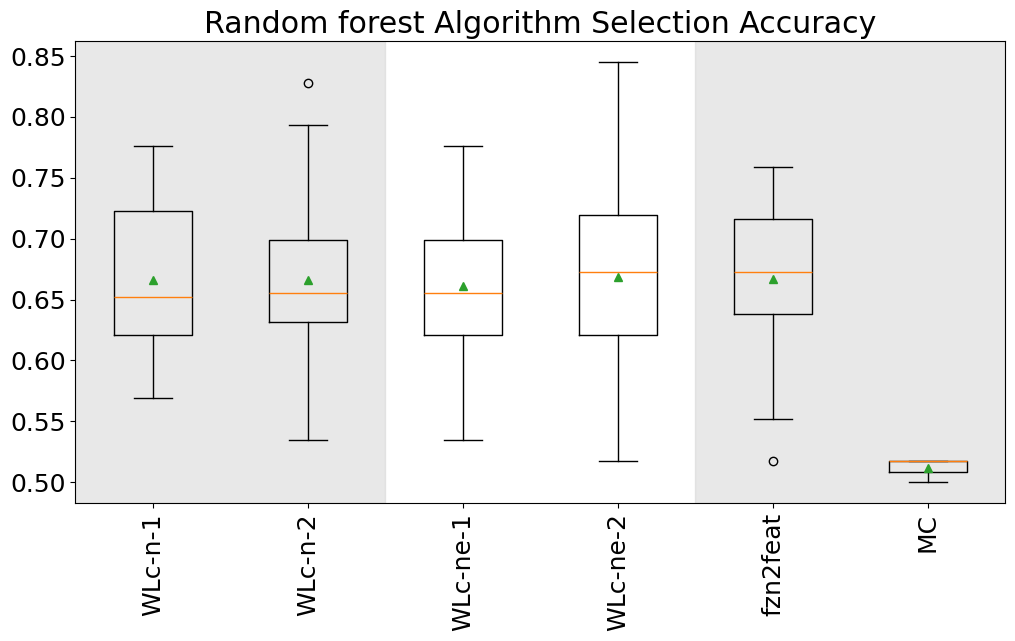

In [58]:
folder = '../data/as-accuracy-results/forest-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_forest = get_as_accuracy_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_forest.items() if 'wlc' in features or 'fzn2feat' in features or 'majority_classifier' in features
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

mc = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = mc

fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(.5, len(plot_res.keys())+.5)
ax.axvspan(0.5, 2.5, color='lightgrey', alpha=0.5)
ax.axvspan(4.5, 6.5, color='lightgrey', alpha=0.5)
ax.set_title("Random forest Algorithm Selection Accuracy")

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wlc", "WLc-n").replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/wl-fzn2feat_accuracy_forest.pdf', format='pdf', bbox_inches='tight',)
plt.show()

../data/as-accuracy-results/forest-scores :


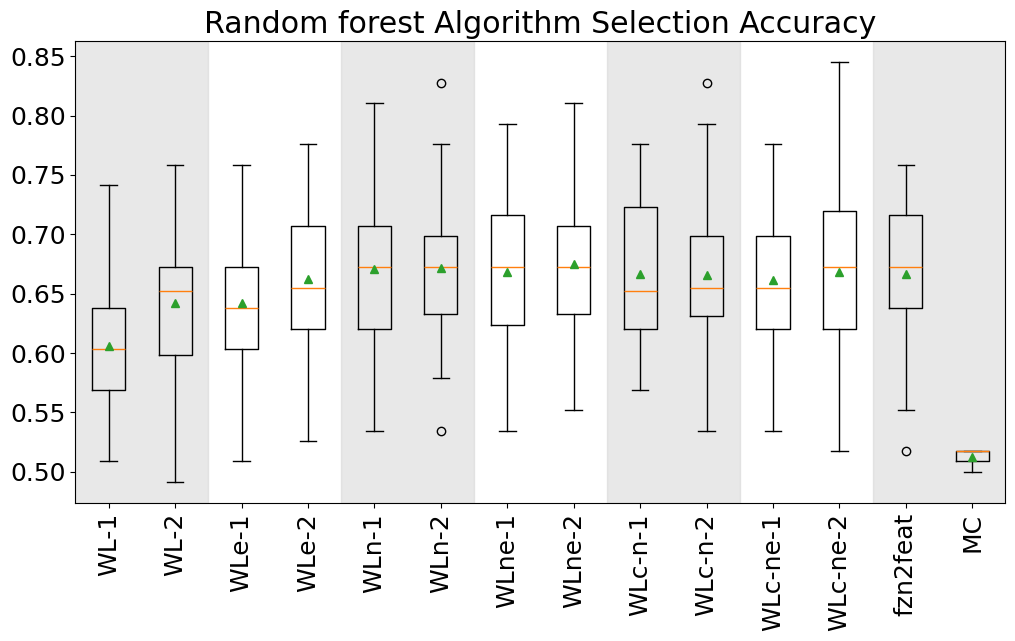

In [61]:
folder = '../data/as-accuracy-results/forest-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_forest = get_as_accuracy_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_forest.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

mc = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = mc

fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(.5, len(plot_res.keys())+.5)
ax.axvspan(0.5, 2.5, color='lightgrey', alpha=0.5)
ax.axvspan(4.5, 6.5, color='lightgrey', alpha=0.5)
ax.axvspan(8.5, 10.5, color='lightgrey', alpha=0.5)
ax.axvspan(12.5, 14.5, color='lightgrey', alpha=0.5)
ax.set_title("Random forest Algorithm Selection Accuracy")

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wlc", "WLc-n").replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/all-wl-fzn2feat_accuracy_forest.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [29]:
print('Statistical significance matrix (fzn2feat -vs- wlc):')
folder = '../data/as-accuracy-results/forest-scores'
WORSE = 'W'
BETTER = 'B'
EQUAL = 'E'

res_svc = get_as_accuracy_results(folder)
features = [f for f in res_svc.keys() if not "alllevels" in f]
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:

        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER + f'({p_value:.3f})'
            else:
                rows[ft2][ft1] = WORSE + f'({p_value:.3f})'
        else:
            rows[ft2][ft1] = EQUAL + f'({p_value:.3f})'
display(pd.DataFrame(rows))

Statistical significance matrix (fzn2feat -vs- wlc):


,fzn2feat,wl-1,wl-2,wle-1,wle-2,wln-1,wln-2,wlne-1,wlne-2,wlc-1,wlc-2,wlce-1,wlce-2,majority_classifier
fzn2feat,E,B(0.000),B(0.028),B(0.044),E(0.775),E(0.788),E(1.000),E(0.962),E(0.498),E(0.795),E(0.639),E(0.739),E(0.834),B(0.000)
wl-1,W(0.000),E,W(0.002),W(0.003),W(0.000),W(0.000),W(0.000),W(0.000),W(0.000),W(0.000),W(0.000),W(0.000),W(0.000),B(0.000)
wl-2,W(0.028),B(0.002),E,E(0.777),E(0.079),W(0.026),W(0.006),W(0.034),W(0.017),W(0.035),W(0.011),E(0.184),W(0.040),B(0.000)
wle-1,W(0.044),B(0.003),E(0.777),E,E(0.087),W(0.019),W(0.006),W(0.017),W(0.002),W(0.021),E(0.098),E(0.082),W(0.035),B(0.000)
wle-2,E(0.775),B(0.000),E(0.079),E(0.087),E,E(0.553),E(0.537),E(0.492),E(0.238),E(0.612),E(0.638),E(0.900),E(0.604),B(0.000)
wln-1,E(0.788),B(0.000),B(0.026),B(0.019),E(0.553),E,E(0.899),E(0.893),E(0.895),E(0.686),E(0.511),E(0.409),E(0.800),B(0.000)
wln-2,E(1.000),B(0.000),B(0.006),B(0.006),E(0.537),E(0.899),E,E(0.891),E(0.870),E(0.755),E(0.504),E(0.285),E(0.797),B(0.000)
wlne-1,E(0.962),B(0.000),B(0.034),B(0.017),E(0.492),E(0.893),E(0.891),E,E(0.615),E(0.913),E(0.635),E(0.571),E(0.924),B(0.000)
wlne-2,E(0.498),B(0.000),B(0.017),B(0.002),E(0.238),E(0.895),E(0.870),E(0.615),E,E(0.528),E(0.529),E(0.262),E(0.593),B(0.000)
wlc-1,E(0.795),B(0.000),W(0.035),B(0.021),E(0.612),E(0.686),E(0.755),E(0.913),E(0.528),E,E(0.857),E(0.835),E(0.783),B(0.000)


In [23]:
table_res = {'last-mean':{}, 
        'all-levels-mean':{}, 
        'last-median':{}, 
        'all-levels-median':{}, 
        'significant': {}}
folder = '../data/as-accuracy-results/forest-scores'


plot_res = get_as_accuracy_results(folder, True)
plot_res = {
    features: list(v.values()) for features, v in plot_res.items()
}
for features in plot_res.keys():
    if not 'alllevels' in features:
        continue
    last_feat = features.replace('_alllevels', '')
    table_res['last-mean'][last_feat.replace("wlc", "WLc-n")] = f'{np.mean(plot_res[last_feat]):.3f}'
    table_res['last-median'][last_feat.replace("wlc", "WLc-n")] = f'{np.median(plot_res[last_feat]):.3f}'
    table_res['all-levels-mean'][last_feat.replace("wlc", "WLc-n")] = f'{np.mean(plot_res[features]):.3f}'
    table_res['all-levels-median'][last_feat.replace("wlc", "WLc-n")] = f'{np.median(plot_res[features]):.3f}'
    _, p = stats.wilcoxon(plot_res[last_feat], plot_res[features])
    table_res['significant'][last_feat.replace("wlc", "WLc-n")] = f'{p:.3f}'

print(pd.DataFrame(table_res).to_latex())

\begin{tabular}{llllll}
\toprule
 & last-mean & all-levels-mean & last-median & all-levels-median & significant \\
\midrule
WLc-n-2 & 0.666 & 0.661 & 0.655 & 0.655 & 0.619 \\
wln-2 & 0.671 & 0.677 & 0.672 & 0.672 & 0.611 \\
WLc-ne-1 & 0.661 & 0.665 & 0.655 & 0.661 & 0.930 \\
wlne-2 & 0.675 & 0.672 & 0.672 & 0.672 & 0.866 \\
WLc-n-1 & 0.666 & 0.669 & 0.652 & 0.655 & 0.615 \\
wln-1 & 0.671 & 0.678 & 0.672 & 0.672 & 0.584 \\
wlne-1 & 0.668 & 0.674 & 0.672 & 0.672 & 0.804 \\
WLc-ne-2 & 0.668 & 0.659 & 0.672 & 0.655 & 0.322 \\
\bottomrule
\end{tabular}



In [70]:
folder = '../data/as-accuracy-results/nn-scores'
print(folder, ':')
res = get_as_accuracy_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print('wlc-1:', p_value)
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print('wlc-2:', p_value)
to_table(res, False)

../data/as-accuracy-results/nn-scores :
wlc-1: 0.3845879891197328
wlc-2: 0.9487907265412397


,Mean,Median,Std,Max,Min
fzn2feat,0.617689,0.620690,0.067278,0.741379,0.465517
wl-1,0.502505,0.500000,0.059983,0.631579,0.379310
wl-2,0.521766,0.517241,0.060430,0.689655,0.362069
wle-1,0.499970,0.508621,0.052422,0.603448,0.413793
wle-2,0.529080,0.534483,0.059897,0.637931,0.413793
wln-1,0.580569,0.586207,0.069791,0.741379,0.448276
wln-2,0.595505,0.586207,0.055933,0.724138,0.431034
wlne-1,0.573678,0.573805,0.063061,0.741379,0.431034
wlne-2,0.594035,0.591349,0.051437,0.689655,0.456140
wlc-1,0.630774,0.637931,0.060029,0.741379,0.491228


In [ ]:
print('wlc-1', compare_as_accuracy_results(('wlc-1', 'nn'),('fzn2feat', 'nn'), '../data/as-accuracy-results'))
print('wlc-2', compare_as_accuracy_results(('wlc-2', 'nn'),('fzn2feat', 'nn'), '../data/as-accuracy-results'))

wlc-1 (0.628719723183391, 0.6245674740484429, 0.6708606766195598)
wlc-2 (0.6214532871972318, 0.6245674740484429, 0.7577952240914199)


../data/as-accuracy-results/nn-scores :
dict_keys(['fzn2feat', 'wl-1', 'wl-2', 'wle-1', 'wle-2', 'wln-1', 'wln-2', 'wlne-1', 'wlne-2', 'wlc-1', 'wlc-2', 'wlce-1', 'wlce-2', 'majority_classifier'])


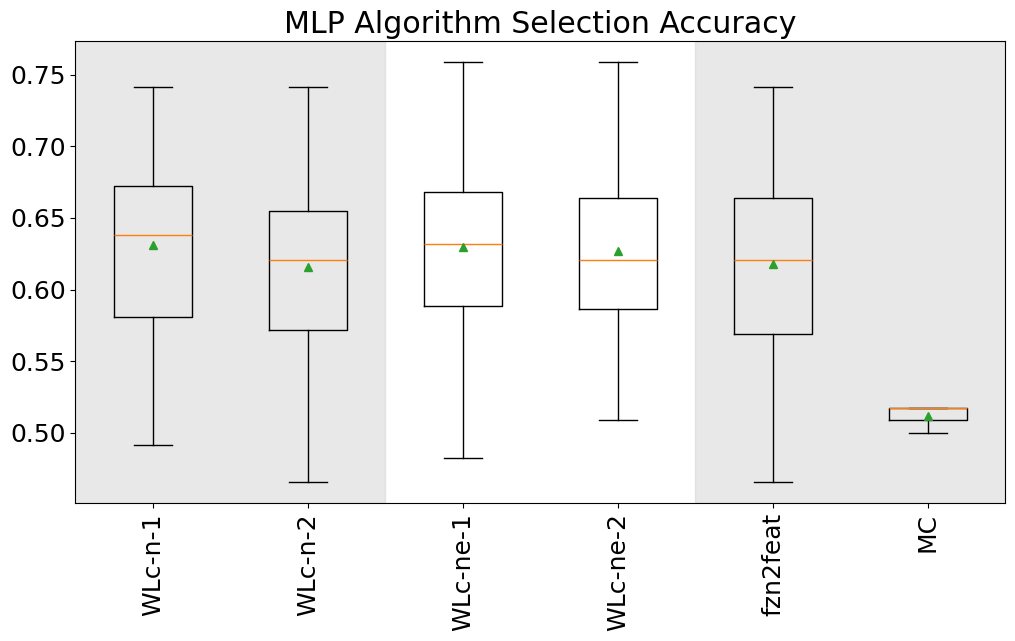

In [55]:
folder = '../data/as-accuracy-results/nn-scores'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_nn = get_as_accuracy_results(folder, False)
print(res_nn.keys())
plot_res = {
    features: list(v.values()) for features, v in res_nn.items() if 'wlc' in features or 'fzn2feat' in features or 'majority_classifier' in features
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

mc = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = mc

fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(.5, len(plot_res.keys())+.5)
ax.axvspan(0.5, 2.5, color='lightgrey', alpha=0.5)
ax.axvspan(4.5, 6.5, color='lightgrey', alpha=0.5)
ax.axvspan(8.5, 10.5, color='lightgrey', alpha=0.5)
ax.set_title("MLP Algorithm Selection Accuracy")

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wlc", "WLc-n") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/wl-fzn2feat_accuracy_nn.pdf', format='pdf', bbox_inches='tight',)
plt.show()

../data/as-accuracy-results/nn-scores :


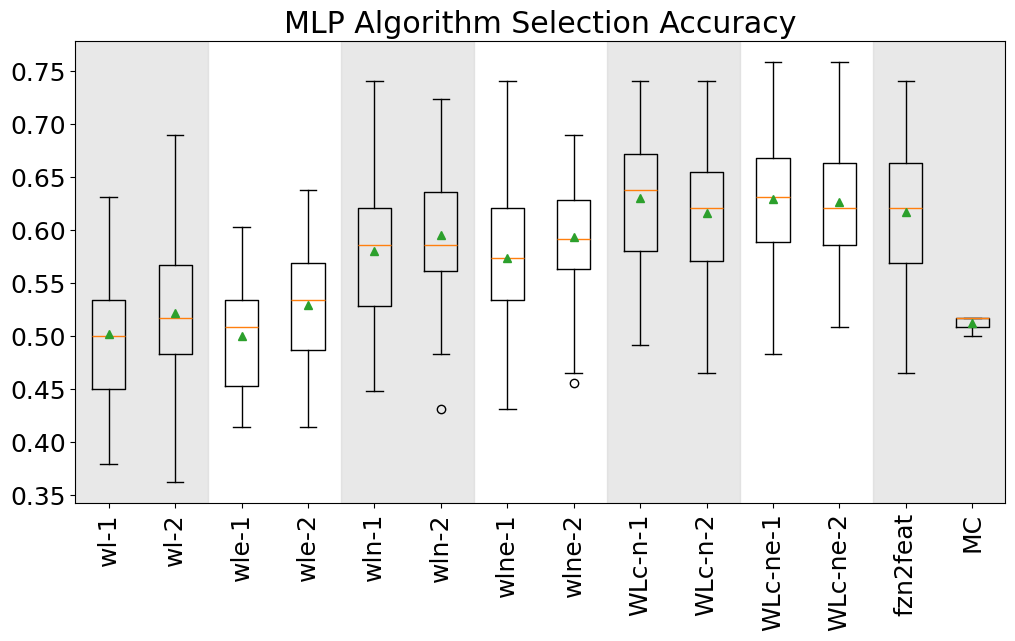

In [68]:
matplotlib.rcParams.update({'font.size': 18})
folder = '../data/as-accuracy-results/nn-scores'

print(folder, ':')
res_nn = get_as_accuracy_results(folder, False)
plot_res = {
    features: list(v.values()) for features, v in res_nn.items() #if 'wlc' in features or 'fzn2feat' in features or 'majority_classifier' in features
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

mc = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = mc

fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(.5, len(plot_res.keys())+.5)
ax.axvspan(0.5, 2.5, color='lightgrey', alpha=0.5)
ax.axvspan(4.5, 6.5, color='lightgrey', alpha=0.5)
ax.axvspan(8.5, 10.5, color='lightgrey', alpha=0.5)
ax.axvspan(12.5, 14.5, color='lightgrey', alpha=0.5)
ax.set_title("MLP Algorithm Selection Accuracy")

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wlc", "WLc-n") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/all-wl-fzn2feat_accuracy_nn.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [69]:
res = get_as_accuracy_results('../data/as-accuracy-results/nn-scores')
fzn2feat = list(res['fzn2feat'].values())
wlc1 = list(res['wlc-1'].values())
wlc2 = list(res['wlc-2'].values())
t_stat, p_value = stats.wilcoxon(wlc1, fzn2feat)
print('wlc-1', p_value, compare_as_accuracy_results(('wlc-1', 'nn'),('fzn2feat', 'nn'), '../data/as-accuracy-results'))
t_stat, p_value = stats.wilcoxon(wlc2, fzn2feat)
print('wlc-2', p_value, compare_as_accuracy_results(('wlc-2', 'nn'),('fzn2feat', 'nn'), '../data/as-accuracy-results'))

wlce1 = list(res['wlce-1'].values())
wlce2 = list(res['wlce-2'].values())
t_stat, p_value = stats.wilcoxon(wlce1, fzn2feat)
print('wlce-1', p_value, compare_as_accuracy_results(('wlce-1', 'nn'),('fzn2feat', 'nn'), '../data/as-accuracy-results'))
t_stat, p_value = stats.wilcoxon(wlce2, fzn2feat)
print('wlce-2', p_value, compare_as_accuracy_results(('wlce-2', 'nn'),('fzn2feat', 'nn'), '../data/as-accuracy-results'))

wlc-1 0.3845879891197328 (0.6307958477508651, 0.6176470588235294, 0.15042104884697804)
wlc-2 0.9487907265412397 (0.615916955017301, 0.6176470588235294, 0.8758021265101571)
wlce-1 0.40882902584208736 (0.629757785467128, 0.6176470588235294, 0.18468527903236426)
wlce-2 0.5081374275870565 (0.626643598615917, 0.6176470588235294, 0.3334045584708228)


In [27]:
table_res = {'last-mean':{}, 
        'all-levels-mean':{}, 
        'last-median':{}, 
        'all-levels-median':{}, 
        'significant': {}}
folder = '../data/as-accuracy-results/nn-scores'


plot_res = get_as_accuracy_results(folder, True)
plot_res = {
    features: list(v.values()) for features, v in plot_res.items()
}
for features in plot_res.keys():
    if not 'alllevels' in features:
        continue
    last_feat = features.replace('_alllevels', '')
    table_res['last-mean'][last_feat] = f'{np.mean(plot_res[last_feat]):.3f}'
    table_res['last-median'][last_feat] = f'{np.median(plot_res[last_feat]):.3f}'
    table_res['all-levels-mean'][last_feat] = f'{np.mean(plot_res[features]):.3f}'
    table_res['all-levels-median'][last_feat] = f'{np.median(plot_res[features]):.3f}'
    _, p = stats.wilcoxon(plot_res[last_feat], plot_res[features])
    table_res['significant'][last_feat] = f'{p:.3f}'

print(pd.DataFrame(table_res).to_latex())

\begin{tabular}{llllll}
\toprule
 & last-mean & all-levels-mean & last-median & all-levels-median & significant \\
\midrule
wlc-2 & 0.621 & 0.624 & 0.626 & 0.621 & 0.690 \\
wlce-1 & 0.613 & 0.614 & 0.621 & 0.621 & 0.964 \\
wlc-1 & 0.629 & 0.620 & 0.621 & 0.621 & 0.526 \\
\bottomrule
\end{tabular}



In [73]:
res_svc = get_as_accuracy_results('../data/as-accuracy-results/svc-scores')
res_forest = get_as_accuracy_results('../data/as-accuracy-results/forest-scores')
fzn2feat = list(res_forest['fzn2feat'].values())
wlc1 = list(res_svc['wlc-1'].values())
wlc2 = list(res_svc['wlc-2'].values())
t_stat, p_value = stats.wilcoxon(wlc1, fzn2feat)
print('wlc-1', p_value, compare_as_accuracy_results(('wlc-1', 'svc'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))
t_stat, p_value = stats.wilcoxon(wlc2, fzn2feat)
print('wlc-2', p_value, compare_as_accuracy_results(('wlc-2', 'svc'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))

wlce1 = list(res_svc['wlce-1'].values())
wlce2 = list(res_svc['wlce-2'].values())
t_stat, p_value = stats.wilcoxon(wlce1, fzn2feat)
print('wlce-1', p_value, compare_as_accuracy_results(('wlce-1', 'svc'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))
t_stat, p_value = stats.wilcoxon(wlce2, fzn2feat)
print('wlce-2', p_value, compare_as_accuracy_results(('wlce-2', 'svc'),('fzn2feat', 'forest'), '../data/as-accuracy-results'))

wlc-1 0.036793817392207114 (0.6948096885813149, 0.6667820069204152, 0.0006394217955246711)
wlc-2 0.10811727228326116 (0.6868512110726643, 0.6667820069204152, 0.014895110247743709)
wlce-1 0.033373173160433166 (0.6930795847750865, 0.6667820069204152, 0.001301728264044362)
wlce-2 0.06788847393297862 (0.6903114186851211, 0.6667820069204152, 0.004071075359870123)


# Parallel Predictions

In [26]:
folder = '../data/parallelise-results/svc-parallelise'
print(folder, ':')
res = get_parallel_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print("wlc-1", p_value, compare_par_results(('wlc-1', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print("wlc-2", p_value, compare_par_results(('wlc-2', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlce-1'].values()), fzn2feat)
print("wlce-1", p_value, compare_par_results(('wlce-1', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlce-2'].values()), fzn2feat)
print("wlce-2", p_value, compare_par_results(('wlce-2', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
display(to_table(res))

../data/parallelise-results/svc-parallelise :
wlc-1 0.9754406622954468 (0.6224080267558528, 0.6224080267558528, 0.9728291975570047)
wlc-2 0.2691755442004541 (0.6107023411371237, 0.6224080267558528, 0.24158985241398526)
wlce-1 0.6876822045635382 (0.6183946488294314, 0.6224080267558528, 0.7072635078841193)
wlce-2 0.844018041781945 (0.6250836120401337, 0.6224080267558528, 0.8057171222296344)


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.622345,0.633333,0.064783,0.733333,0.450000,0
wl-1,0.569237,0.559322,0.065106,0.683333,0.416667,0
wl-2,0.594966,0.600000,0.074699,0.783333,0.440678,0
wle-1,0.558141,0.566667,0.069771,0.683333,0.350000,0
wle-2,0.562153,0.550000,0.066482,0.733333,0.450000,0
wln-1,0.624802,0.616667,0.060718,0.750000,0.516667,0
wln-2,0.604028,0.600000,0.064954,0.728814,0.500000,0
wlne-1,0.633119,0.627119,0.056318,0.766667,0.516667,0
wlne-2,0.604367,0.600000,0.064464,0.733333,0.500000,0
wlc-1,0.622339,0.633333,0.062975,0.800000,0.500000,0


../data/parallelise-results/svc-parallelise :


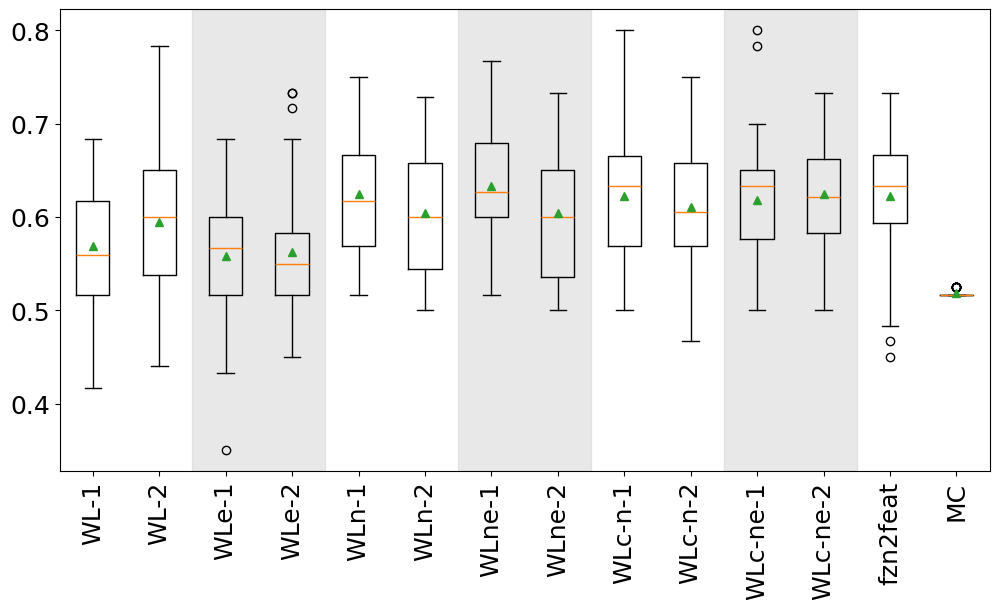

In [25]:
folder = '../data/parallelise-results/svc-parallelise'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_parallel_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

majority_classifier = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = majority_classifier
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wlc", "WLc-n").replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/wl_par_svc.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [27]:
table_res = {'last-mean':{}, 
        'all-levels-mean':{}, 
        'last-median':{}, 
        'all-levels-median':{}, 
        'significant': {}}
folder = '../data/parallelise-results/svc-parallelise'


plot_res = get_parallel_results(folder, True)
plot_res = {
    features: list(v.values()) for features, v in plot_res.items()
}
for features in plot_res.keys():
    if not 'alllevels' in features:
        continue
    last_feat = features.replace('_alllevels', '')
    table_res['last-mean'][last_feat.replace("wlc", "WLc-n")] = f'{np.mean(plot_res[last_feat]):.3f}'
    table_res['last-median'][last_feat.replace("wlc", "WLc-n")] = f'{np.median(plot_res[last_feat]):.3f}'
    table_res['all-levels-mean'][last_feat.replace("wlc", "WLc-n")] = f'{np.mean(plot_res[features]):.3f}'
    table_res['all-levels-median'][last_feat.replace("wlc", "WLc-n")] = f'{np.median(plot_res[features]):.3f}'
    _, p = stats.wilcoxon(plot_res[last_feat], plot_res[features])
    table_res['significant'][last_feat.replace("wlc", "WLc-n")] = f'{p:.3f}'

print(pd.DataFrame(table_res).to_latex())

\begin{tabular}{llllll}
\toprule
 & last-mean & all-levels-mean & last-median & all-levels-median & significant \\
\midrule
WLc-n-1 & 0.622 & 0.620 & 0.633 & 0.617 & 0.935 \\
WLc-ne-2 & 0.625 & 0.628 & 0.622 & 0.625 & 0.851 \\
WLc-n-2 & 0.611 & 0.626 & 0.605 & 0.617 & 0.327 \\
wln-1 & 0.625 & 0.619 & 0.617 & 0.633 & 0.615 \\
wlne-2 & 0.604 & 0.601 & 0.600 & 0.600 & 0.845 \\
wln-2 & 0.604 & 0.615 & 0.600 & 0.617 & 0.438 \\
WLc-ne-1 & 0.618 & 0.627 & 0.633 & 0.622 & 0.295 \\
wlne-1 & 0.633 & 0.610 & 0.627 & 0.617 & 0.095 \\
\bottomrule
\end{tabular}



In [79]:
print('Statistical significance matrix (no fzn2feat):')
folder = '../data/parallelise-results/svc-parallelise'
WORSE = '\\textcolor{red}{$\\times$}'
BETTER = '\\textcolor{ForestGreen}{\\checkmark}'
EQUAL = '\\textbf{--}'

res_svc = get_parallel_results(folder)
features = [f for f in res_svc.keys() if f != 'fzn2feat' and f != 'majority_classifier']
features.append('fzn2feat')
features.append('majority_classifier')
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:
        # if ft1 in ['wl-2', 'wle-2'] or ft2 in ['wl-2', 'wle-2']:
        #     continue
        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
            _, _, p_value = compare_par_results((ft1, 'svc'),(ft2, 'svc'), '../data/parallelise-results')
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER
            else:
                rows[ft2][ft1] = WORSE
        else:
            rows[ft1][ft2] = EQUAL
print(pd.DataFrame(rows).to_latex())

Statistical significance matrix (no fzn2feat):
\begin{tabular}{lllllllllllllll}
\toprule
 & wl-1 & wl-2 & wle-1 & wle-2 & wln-1 & wln-2 & wlne-1 & wlne-2 & wlc-1 & wlc-2 & wlce-1 & wlce-2 & fzn2feat & majority_classifier \\
\midrule
wl-1 & \textbf{--} & \textcolor{red}{$\times$} & \textbf{--} & \textbf{--} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{ForestGreen}{\checkmark} \\
wl-2 & \textcolor{ForestGreen}{\checkmark} & \textbf{--} & \textcolor{ForestGreen}{\checkmark} & \textcolor{ForestGreen}{\checkmark} & \textcolor{red}{$\times$} & \textbf{--} & \textcolor{red}{$\times$} & \textbf{--} & \textcolor{red}{$\times$} & \textbf{--} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{red}{$\times$} & \textcolor{ForestGreen}{\checkmark} \\
wle-1 & \textbf

In [78]:
print('Statistical significance matrix (no fzn2feat):')
folder = '../data/parallelise-results/nn-parallelise'
WORSE = 'W'
BETTER = 'B'
EQUAL = 'E'

res_svc = get_parallel_results(folder)
features = [f for f in res_svc.keys() if 'wlc' in f or 'wln' in f]
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:
        # if ft1 in ['wl-2', 'wle-2'] or ft2 in ['wl-2', 'wle-2']:
        #     continue
        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
            _, _, p_value = compare_par_results((ft1, 'forest'),(ft2, 'forest'), '../data/parallelise-results')
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER
            else:
                rows[ft2][ft1] = WORSE
        else:
            rows[ft1][ft2] = EQUAL
pd.DataFrame(rows)

Statistical significance matrix (no fzn2feat):


,wln-1,wln-2,wlne-1,wlne-2,wlc-1,wlc-2,wlce-1,wlce-2
wln-1,E,E,E,E,E,E,W,E
wln-2,E,E,E,E,E,E,E,E
wlne-1,E,E,E,E,E,E,E,E
wlne-2,E,E,E,E,E,E,E,E
wlc-1,E,E,E,E,E,E,E,E
wlc-2,E,E,E,E,E,E,W,E
wlce-1,B,E,E,E,E,W,E,E
wlce-2,E,E,E,E,E,E,E,E


In [2]:
folder = '../data/parallelise-results/nn-parallelise'
print(folder, ':')
res = get_parallel_results(folder)
fzn2feat = list(res['fzn2feat'].values())
t_stat, p_value = stats.wilcoxon(list(res['wlc-1'].values()), fzn2feat)
print("wlc-1", p_value, compare_par_results(('wlc-1', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlc-2'].values()), fzn2feat)
print("wlc-2", p_value, compare_par_results(('wlc-2', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlce-1'].values()), fzn2feat)
print("wlce-1", p_value, compare_par_results(('wlce-1', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
t_stat, p_value = stats.wilcoxon(list(res['wlce-2'].values()), fzn2feat)
print("wlce-2", p_value, compare_par_results(('wlce-2', 'svc'),('fzn2feat', 'svc'), '../data/parallelise-results'))
display(to_table(res))

../data/parallelise-results/nn-parallelise :
wlc-1 0.08661707684955672 (0.6224080267558528, 0.6224080267558528, 0.9728291975570047)
wlc-2 0.25370121992314276 (0.6107023411371237, 0.6224080267558528, 0.24158985241398526)
wlce-1 0.14825676959567397 (0.6183946488294314, 0.6224080267558528, 0.7072635078841193)
wlce-2 0.13281381535555864 (0.6250836120401337, 0.6224080267558528, 0.8057171222296344)


,Mean,Median,Std,Max,Min,Worse_sbs
fzn2feat,0.662904,0.666667,0.057114,0.796610,0.508475,0
wl-1,0.593000,0.588277,0.049960,0.733333,0.500000,0
wl-2,0.601667,0.613418,0.060776,0.733333,0.466667,0
wle-1,0.589927,0.583333,0.066915,0.716667,0.416667,0
wle-2,0.590181,0.591667,0.059432,0.716667,0.457627,0
wln-1,0.621328,0.633333,0.062818,0.733333,0.450000,0
wln-2,0.621734,0.630226,0.055575,0.716667,0.483333,0
wlne-1,0.618006,0.621893,0.059266,0.733333,0.483333,0
wlne-2,0.617633,0.630226,0.055884,0.716667,0.457627,0
wlc-1,0.644492,0.633333,0.061079,0.833333,0.483333,0


../data/parallelise-results/nn-parallelise :


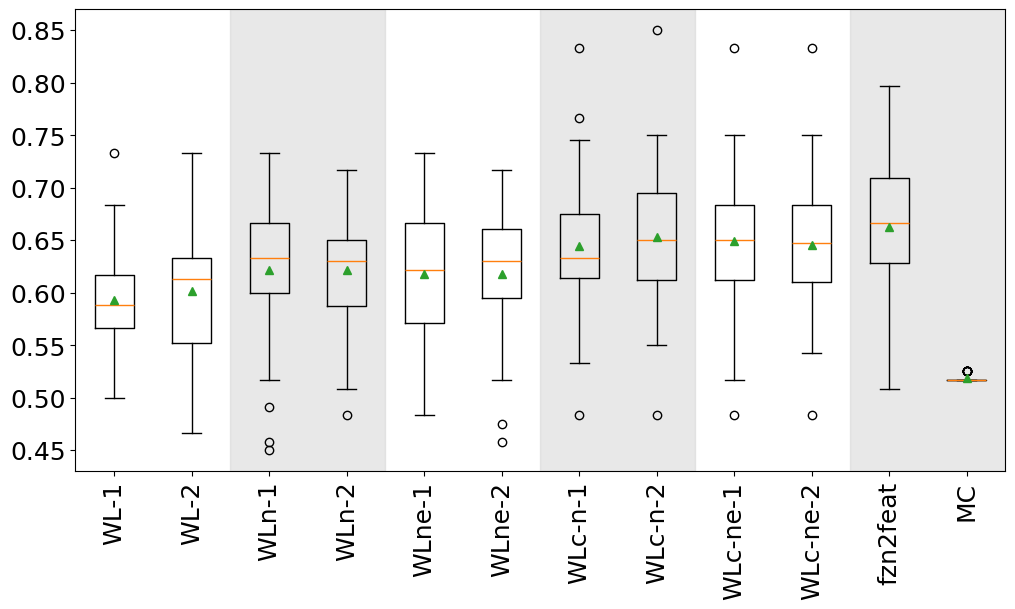

In [28]:
folder = '../data/parallelise-results/nn-parallelise'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_parallel_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

majority_classifier = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = majority_classifier
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wlc", "WLc-n").replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/par_nn.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [77]:
print('Statistical significance matrix (no fzn2feat):')
folder = '../data/parallelise-results/nn-parallelise'
WORSE = 'W'
BETTER = 'B'
EQUAL = 'E'

res_svc = get_parallel_results(folder)
features = [f for f in res_svc.keys() if 'wlc' in f or 'wln' in f]
features.append('fzn2feat')
features.append('majority_classifier')
rows = {feat:{ft:'' for ft in features} for feat in features}
for ft1 in features:
    for ft2 in features:
        # if ft1 in ['wl-2', 'wle-2'] or ft2 in ['wl-2', 'wle-2']:
        #     continue
        if ft1 == ft2:
            rows[ft1][ft2] = EQUAL
            continue
        ft1_results = list(res_svc[ft1].values())
        ft2_results = list(res_svc[ft2].values())
        try:
            _, p_value = stats.wilcoxon(ft1_results, ft2_results)
            _, _, p_value = compare_par_results((ft1, 'nn'),(ft2, 'nn'), '../data/parallelise-results')
        except Exception as e:
            print(ft1, ft2)
            raise e
        if p_value < .05:
            if np.median(ft1_results) > np.median(ft2_results):
                rows[ft2][ft1] = BETTER
            else:
                rows[ft2][ft1] = WORSE
        else:
            rows[ft1][ft2] = EQUAL
pd.DataFrame(rows)

Statistical significance matrix (no fzn2feat):


,wln-1,wln-2,wlne-1,wlne-2,wlc-1,wlc-2,wlce-1,wlce-2,fzn2feat,majority_classifier
wln-1,E,E,E,E,W,W,W,W,W,B
wln-2,E,E,E,E,W,W,W,W,W,B
wlne-1,E,E,E,E,W,W,W,W,W,B
wlne-2,E,E,E,E,W,W,W,W,W,B
wlc-1,W,B,B,B,E,E,E,E,E,B
wlc-2,B,B,B,B,E,E,E,E,E,B
wlce-1,B,B,B,B,E,E,E,E,E,B
wlce-2,B,B,B,B,E,E,E,E,E,B
fzn2feat,B,B,B,B,E,E,E,E,E,B
majority_classifier,W,W,W,W,W,W,W,W,W,E


In [32]:
table_res = {'last-mean':{}, 
        'all-levels-mean':{}, 
        'last-median':{}, 
        'all-levels-median':{}, 
        'significant': {}}
folder = '../data/parallelise-results/nn-parallelise'


plot_res = get_parallel_results(folder, True)
plot_res = {
    features: list(v.values()) for features, v in plot_res.items()
}
for features in plot_res.keys():
    if not 'alllevels' in features:
        continue
    if features == 'wlce-1_alllevels':
        continue
    last_feat = features.replace('_alllevels', '')
    table_res['last-mean'][last_feat] = f'{np.mean(plot_res[last_feat]):.3f}'
    table_res['last-median'][last_feat] = f'{np.median(plot_res[last_feat]):.3f}'
    table_res['all-levels-mean'][last_feat] = f'{np.mean(plot_res[features]):.3f}'
    table_res['all-levels-median'][last_feat] = f'{np.median(plot_res[features]):.3f}'
    _, p = stats.wilcoxon(plot_res[last_feat], plot_res[features])
    table_res['significant'][last_feat] = f'{p:.3f}'

print(pd.DataFrame(table_res).to_latex())

\begin{tabular}{llllll}
\toprule
 & last-mean & all-levels-mean & last-median & all-levels-median & significant \\
\midrule
wlc-2 & 0.652 & 0.649 & 0.650 & 0.650 & 0.984 \\
wlc-1 & 0.647 & 0.650 & 0.633 & 0.650 & 0.891 \\
\bottomrule
\end{tabular}



In [50]:
for folder in ['../data/parallelise-results/forest-parallelise']:
    print(folder, ':')
    res = get_parallel_results(folder)
    fzn2feat = list(res['fzn2feat'].values())
    wlc1_forest = list(res['wlc-1'].values())
    t_stat, p_value = stats.wilcoxon(wlc1_forest, fzn2feat)
    print(p_value)
    display(to_table(res, False))

../data/parallelise-results/forest-parallelise :
5.2457127247969787e-05


,Mean,Median,Std,Max,Min
fzn2feat,0.575960,0.554661,0.074277,0.716667,0.383333
wl-1,0.595410,0.616667,0.054316,0.683333,0.483333
wl-2,0.629056,0.633333,0.050199,0.750000,0.491525
wle-1,0.642119,0.644068,0.051935,0.750000,0.516667
wle-2,0.648215,0.650000,0.059904,0.783333,0.500000
wln-1,0.634780,0.650000,0.056965,0.745763,0.416667
wln-2,0.645164,0.644068,0.051312,0.766667,0.533333
wlne-1,0.642763,0.647034,0.062914,0.800000,0.433333
wlne-2,0.642136,0.650000,0.054797,0.745763,0.483333
wlc-1,0.641774,0.633333,0.059415,0.766667,0.466667


../data/parallelise-results/forest-parallelise :


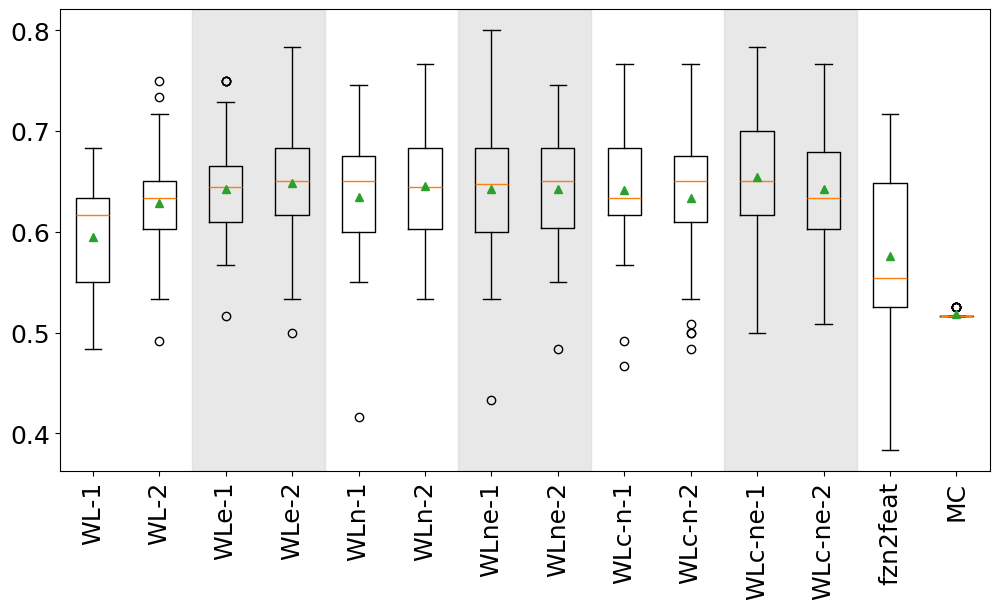

In [29]:
folder = '../data/parallelise-results/forest-parallelise'
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 18})
print(folder, ':')
res_svc = get_parallel_results(folder)
plot_res = {
    features: list(v.values()) for features, v in res_svc.items()
}
fzn2feat = plot_res['fzn2feat']
del plot_res['fzn2feat']
plot_res['fzn2feat'] = fzn2feat

majority_classifier = plot_res['majority_classifier']
del plot_res['majority_classifier']
plot_res['majority_classifier'] = majority_classifier
fig, ax = plt.subplots(figsize=(12,6))
violin_parts = ax.boxplot(plot_res.values(), showmeans=True)

ax.set_xlim(0.5, len(plot_res.keys())+.5)
ax.axvspan(2.5, 4.5, color='lightgrey', alpha=0.5)
ax.axvspan(6.5, 8.5, color='lightgrey', alpha=0.5)
ax.axvspan(10.5, 12.5, color='lightgrey', alpha=0.5)

plt.xticks([i for i in range(1, len(plot_res.keys())+1)], [
    k.replace("wlc", "WLc-n").replace("wl", "WL") if k != 'majority_classifier' else 'MC' for k in plot_res.keys()], 
    rotation='vertical')
plt.savefig('../paper/figures/par_forest.pdf', format='pdf', bbox_inches='tight',)
plt.show()

In [40]:
table_res = {'last-mean':{}, 
        'all-levels-mean':{}, 
        'last-median':{}, 
        'all-levels-median':{}, 
        'significant': {}}
folder = '../data/parallelise-results/forest-parallelise'


plot_res = get_parallel_results(folder, True)
plot_res = {
    features: list(v.values()) for features, v in plot_res.items()
}
for features in plot_res.keys():
    if not 'alllevels' in features:
        continue
    last_feat = features.replace('_alllevels', '')
    table_res['last-mean'][last_feat] = f'{np.mean(plot_res[last_feat]):.3f}'
    table_res['last-median'][last_feat] = f'{np.median(plot_res[last_feat]):.3f}'
    table_res['all-levels-mean'][last_feat] = f'{np.mean(plot_res[features]):.3f}'
    table_res['all-levels-median'][last_feat] = f'{np.median(plot_res[features]):.3f}'
    _, p = stats.wilcoxon(plot_res[last_feat], plot_res[features])
    table_res['significant'][last_feat] = f'{p:.3f}'

print(pd.DataFrame(table_res).to_latex())

\begin{tabular}{llllll}
\toprule
 & last-mean & all-levels-mean & last-median & all-levels-median & significant \\
\midrule
wln-1 & 0.635 & 0.645 & 0.650 & 0.650 & 0.369 \\
wlc-1 & 0.642 & 0.651 & 0.633 & 0.650 & 0.409 \\
wlc-2 & 0.634 & 0.638 & 0.650 & 0.650 & 0.658 \\
wlne-2 & 0.642 & 0.648 & 0.650 & 0.650 & 0.631 \\
wlce-1 & 0.654 & 0.645 & 0.650 & 0.633 & 0.435 \\
wlne-1 & 0.643 & 0.634 & 0.647 & 0.633 & 0.464 \\
wlce-2 & 0.643 & 0.649 & 0.633 & 0.661 & 0.619 \\
wln-2 & 0.645 & 0.650 & 0.644 & 0.650 & 0.476 \\
\bottomrule
\end{tabular}



# Feature Extraction Cost

In [ ]:
wlc1 = pd.read_csv('../data/wlc1_extraction.csv')
wlc2 = pd.read_csv('../data/wlc2_extraction.csv')
fzn2feat = pd.read_csv('../data/fzn2feat_extraction.csv')

In [3]:
wlc1['wlc1_time'] = wlc1['time']
wlc1 = wlc1.drop(columns=['time'])
wlc2['wlc2_time'] = wlc2['time']
wlc2 = wlc2.drop(columns=['time'])
fzn2feat['fzn2feat_time'] = fzn2feat['time']
fzn2feat = fzn2feat.drop(columns=['time'])

In [4]:
merged = wlc1.merge(wlc2, on='name').merge(fzn2feat, on='name')
merged

,name,wlc1_time,wlc2_time,fzn2feat_time
0,portal-sep-small_3,0.102439,0.102300,0.022730
1,portal-sep-random_10_9_10,0.041639,0.039833,0.011155
2,portal-sep-random_20_9_100,0.654443,0.680940,0.183309
3,portal-sep-random_20_1_100,0.671200,0.689228,0.197974
4,portal-sep-random_10_0_100,0.559645,0.596811,0.096380
...,...,...,...,...
294,chessboard-sep-chessboard_n9_1,0.043767,0.040159,0.008906
295,chessboard-sep-chessboard4,0.025524,0.032808,0.008466
296,chessboard-sep-chessboard_n39_2,0.965886,1.007597,0.175322
297,chessboard-sep-chessboard3,0.026218,0.025014,0.008597


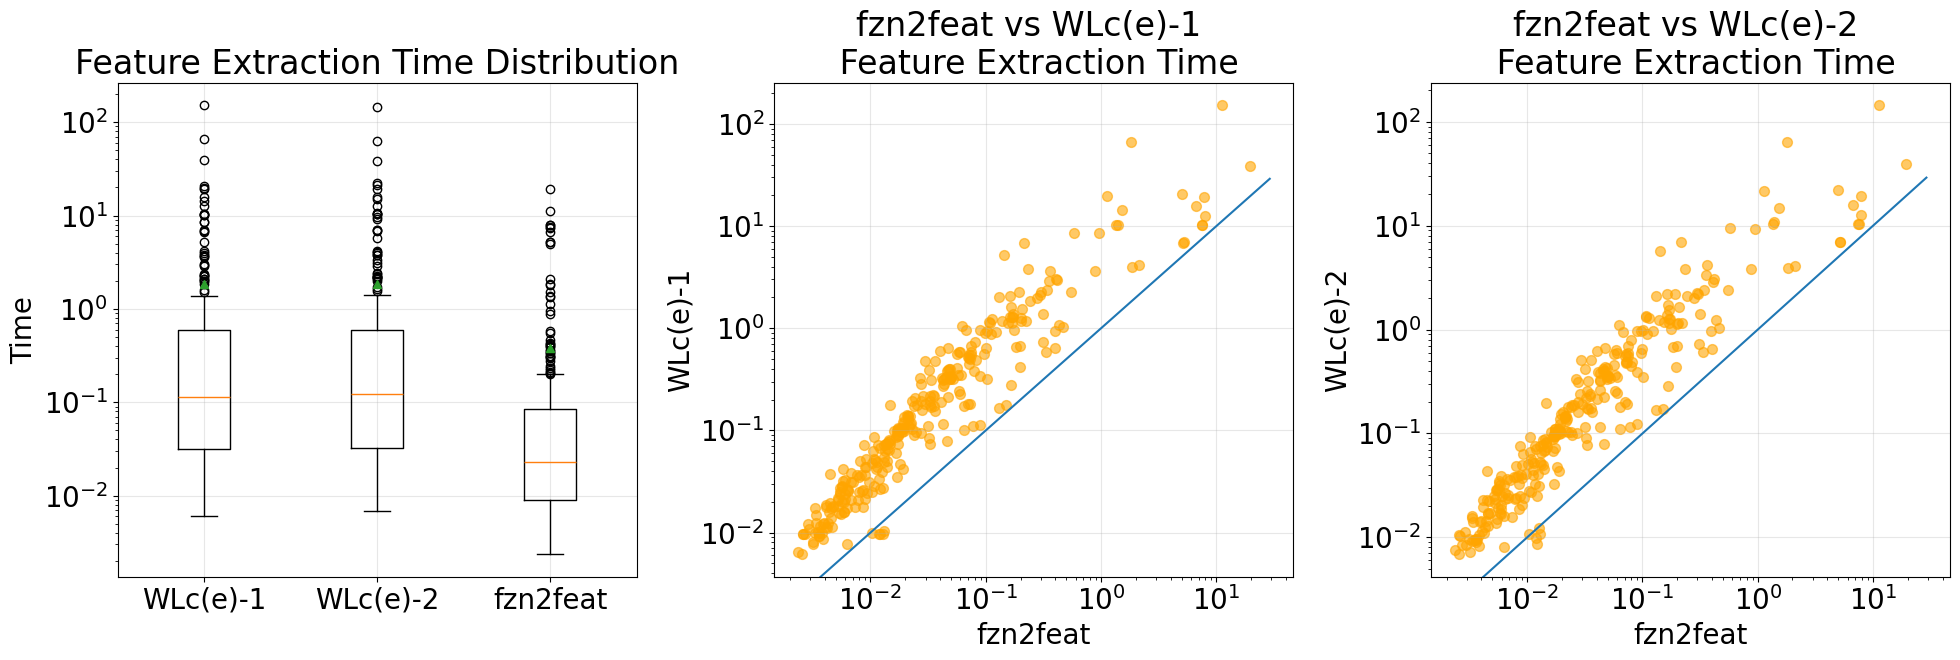

In [6]:
matplotlib.rcParams['font.family'] = 'sans-serif'

matplotlib.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
# 1. Boxplot - each time column as a separate box
time_columns = ['wlc1_time', 'wlc2_time', 'fzn2feat_time']
# merged[time_columns].boxplot(ax=axes[0])
axes[0].boxplot(merged[time_columns], showmeans=True)
axes[0].set_title('Feature Extraction Time Distribution')
axes[0].set_ylabel('Time')
axes[0].set_xticklabels(['WLc(e)-1', 'WLc(e)-2', 'fzn2feat'])
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# 2. First scatter plot: fzn2feat_time vs wlc1_time
axes[1].scatter(merged['fzn2feat_time'], merged['wlc1_time'], alpha=0.6, s=50, color='orange')
axes[1].plot([i for i in range(30)], [i for i in range(30)])
axes[1].set_xlabel('fzn2feat')
axes[1].set_ylabel('WLc(e)-1')
axes[1].set_title('fzn2feat vs WLc(e)-1 \n Feature Extraction Time')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')
axes[1].set_xscale('log')


# 3. Second scatter plot: fzn2feat_time vs wlc2_time
axes[2].scatter(merged['fzn2feat_time'], merged['wlc2_time'], alpha=0.6, s=50, color='orange')
axes[2].plot([i for i in range(30)], [i for i in range(30)])
axes[2].set_xlabel('fzn2feat')
axes[2].set_ylabel('WLc(e)-2')
axes[2].set_title('fzn2feat vs WLc(e)-2 \n Feature Extraction Time')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')
axes[2].set_xscale('log')

# Adjust layout to prevent overlap
plt.tight_layout()

plt.savefig('../paper/figures/feature_extraction.pdf', format='pdf', bbox_inches='tight')
# Display the plot
plt.show()